
# Multi-Compartment Halophyte Hydraulic Model

This notebook runs the multi-compartment halophyte groundwater model with salt dynamics using weather data.

**Model Features:**
- Multi-compartment soil system with independent moisture and salt dynamics
- Bartlett et al. (2012) plant water potential formulation
- Algebraic water balance enforcement at root/soil interface
- Numerical water balance at xylem junction

**Key Parameters:**
- Duration: Simulation length in days
- Initial soil moisture and salt concentrations per compartment
- Root distribution across compartments
- Plant storage initial conditions

In [121]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [122]:

# Import required libraries
import os
import numpy as np
import pandas as pd
from math import exp, pi, sqrt, log
import matplotlib.pyplot as plt
import importlib

# Import model components
from dics import *
from functions import *
from species_traits import *

# Import multi-compartment classes
from soil import SoilMultiple, Loam, DrydownSoil
import hydraulics
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3, C3_cs_reduc

print("Libraries imported successfully")

Libraries imported successfully


## Configuration & Parameter Setup
Define simulation parameters for multi-compartment system.

In [123]:
# Simulation configuration
duration = 14  # Simulation duration (days)
timestepM = 30  # Model timestep (minutes)
dt = timestepM * 60.0  # Convert to seconds

# Weather data file
weatherFile = r"sample_data\AgadirInterp30.xlsx"

# Multi-compartment configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])  # Root zone depth for each compartment (m)
s_init_arr = np.array([0.4, 0.4]) #np.array([0.5, 0.5])  # Initial soil moisture for each compartment
cs_init_arr = np.array([35., 35.])  # Initial salt concentration (Mol/m³) Upper thershold treatment in Sanchez-Ledsma et al. 2022
root_frac_arr = np.array([0.5, 0.5])  # Root fraction in each compartment

# Hydraulic parameters
B_param = 500  # Root conductance scaling parameter

# Plant water potential parameters (Bartlett et al. 2012)
wr = 0.1  # Wilting point relative water content
wft = 1.0  # Full turgor relative water content
pi0 = -1.8  # Osmotic potential at full turgor (MPa)
eta = 5  # Elastic modulus shape parameter
mcap = 12  # Slope of linear portion of psi_wf curve

# Plant initial conditions
vwi = 0.95  # Initial storage volume fraction
cw_init = 5.  # Initial plant salt concentration (Mol/m³)
# pi0 = cw_init * R * T/vwi  # Calculate pi0 from initial concentration

print(f"Simulation duration: {duration} days")
print(f"Timestep: {timestepM} minutes")
print(f"Number of compartments: {num_compartments}")
print(f"Root distribution: {root_frac_arr}")
print(f"Initial soil moisture: {s_init_arr}")
print(f"Initial salt concentrations: {cs_init_arr} Mol/m³")

Simulation duration: 14 days
Timestep: 30 minutes
Number of compartments: 2
Root distribution: [0.5 0.5]
Initial soil moisture: [0.4 0.4]
Initial salt concentrations: [35. 35.] Mol/m³


## Load Weather Data
Read weather input from Excel file (temperature, humidity, solar radiation).

In [124]:
# Load weather data from Excel
df = pd.read_excel(weatherFile, engine='openpyxl')

# Extract and convert temperature to Kelvin
tempC = df['Temperature']  # in Celsius
taInp = tempC + 273.0
taInp = list(taInp.values)

# Extract relative humidity and convert to specific humidity (kg/kg)
rh = df['Relative Humidity']  # in %
A_SAT = 611.2  # Pa
B_SAT = 17.67
C_SAT = 243.5  # °C
P_ATM = 101325  # Pa
psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))  # Saturated vapor pressure (Pa)
qaInp = 0.622 * rh / 100.0 * psat / P_ATM
qaInp = list(qaInp.values)

# Extract solar radiation (global horizontal irradiance)
phiInp = list(df['GHI'].values)  # W/m²

print(f"Weather data loaded: {len(taInp)} timesteps")
print(f"Temperature range: {min(tempC):.1f} - {max(tempC):.1f} °C")
print(f"Solar radiation range: {min(phiInp):.1f} - {max(phiInp):.1f} W/m²")

Weather data loaded: 17521 timesteps
Temperature range: 11.0 - 33.1 °C
Solar radiation range: 0.0 - 781.9 W/m²



## Initialize Model Components
Set up species, soil, atmosphere, photosynthesis, and hydraulic components.


In [125]:
# Build two comparable simulations with different photosynthesis models
model_builders = {
    'C3_cs_reduc': lambda species_obj, atmosphere_obj: C3_cs_reduc(species_obj, atmosphere_obj, cs_init_arr),
    'C3': lambda species_obj, atmosphere_obj: C3(species_obj, atmosphere_obj),
}

def initialize_simulation(model_name):
    species_obj = Pecan()
    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])

    soil_obj = SoilMultiple(
        stype=Loam(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=cs_init_arr
    )

    photo_obj = model_builders[model_name](species_obj, atmosphere_obj)

    hydro_obj = hydraulics.Halophyte(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi=vwi,
        cw=cw_init,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr=wr,
        wft=wft,
        pi0=pi0,
        eta=eta,
        mcap=mcap,
        dt=dt,
        psi_wf_mode='bartlett'  # Switch to 'legacy' to revert to prior formulation
    )

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt
    )

    return plant_obj, hydro_obj

model_runs = {}
for model_name in model_builders:
    plant_obj, hydro_obj = initialize_simulation(model_name)
    model_runs[model_name] = {'plant': plant_obj, 'hydro': hydro_obj}
    print(f"{model_name} initialized:")
    print(f"  Initial plant water content: {hydro_obj.w:.3f}")
    print(f"  Initial plant salt concentration: {hydro_obj.cw:.1f} Mol/m³")
    print(f"  Initial leaf water potential: {hydro_obj.psi_l:.3f} MPa")

# Keep one default model handle for downstream cells
primary_model_key = 'C3_cs_reduc'
plant = model_runs[primary_model_key]['plant']
hydro = model_runs[primary_model_key]['hydro']

print("\nMulti-model setup complete")
print(f"Default results model for downstream cells: {primary_model_key}")

C3_cs_reduc initialized:
  Initial plant water content: 0.950
  Initial plant salt concentration: 5.0 Mol/m³
  Initial leaf water potential: -0.370 MPa
C3 initialized:
  Initial plant water content: 0.950
  Initial plant salt concentration: 5.0 Mol/m³
  Initial leaf water potential: -0.370 MPa

Multi-model setup complete
Default results model for downstream cells: C3_cs_reduc


In [126]:
# Select model variants to run in the next cell
selected_models = ['C3_cs_reduc', 'C3']
print(f"Selected model variants: {selected_models}")

Selected model variants: ['C3_cs_reduc', 'C3']


## Run Simulation
Advance the model through each timestep using weather data.

In [127]:
# Run selected model variants
print(f"\nRunning simulation for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

if 'selected_models' not in globals() or selected_models is None:
    selected_models = list(model_runs.keys())

results_by_model = {}
for model_name in selected_models:
    if model_name not in model_runs:
        raise ValueError(f"Model '{model_name}' is not initialized. Available: {list(model_runs.keys())}")

    plant_model = model_runs[model_name]['plant']
    print(f"\nStarting {model_name}...")

    for i in range(n_steps):
        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])

        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {model_name}: {i+1}/{n_steps} timesteps ({(i+1)/n_steps*100:.1f}%)")

    results_by_model[model_name] = plant_model.output()
    print(f"Completed {model_name}")

# Keep the default single-model variable used by downstream cells
if primary_model_key in results_by_model:
    results = results_by_model[primary_model_key]
else:
    fallback_key = list(results_by_model.keys())[0]
    results = results_by_model[fallback_key]
    print(f"Primary model not run; using '{fallback_key}' as default results")

print("\nAll simulations complete!")
print(f"Available models: {list(results_by_model.keys())}")
print(f"Default results keys: {list(results.keys())}")


Running simulation for 14 days...

Starting C3_cs_reduc...
  C3_cs_reduc: 1/672 timesteps (0.1%)
  C3_cs_reduc: 168/672 timesteps (25.0%)
  C3_cs_reduc: 336/672 timesteps (50.0%)
  C3_cs_reduc: 504/672 timesteps (75.0%)
  C3_cs_reduc: 672/672 timesteps (100.0%)
Completed C3_cs_reduc

Starting C3...
  C3: 1/672 timesteps (0.1%)
  C3: 168/672 timesteps (25.0%)
  C3: 336/672 timesteps (50.0%)
  C3: 504/672 timesteps (75.0%)
  C3: 672/672 timesteps (100.0%)
Completed C3

All simulations complete!
Available models: ['C3_cs_reduc', 'C3']
Default results keys: ['a', 'psi_l_reduc', 'cs_reduc', 'psi_l', 'qs', 'gp', 'gsr', 'gsw', 'tl', 'ev', 'ev_cum', 'qw', 'vw', 'cw', 'psi_w', 'psi_w_turgor', 'psi_w_osm', 'psi_x', 'psi_b', 'gwf', 'w', 'flux_balance', 'hr_cum', 'Uptake', 'MW', 'delta psi w', 'qbx', 's', 'psi_s', 'cs']


In [128]:
results_by_model[model_a]['psi_l_reduc']

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 np.float64(0.14479583492078218),
 np.float64(0.37961574053112457),
 np.float64(0.5206798434211082),
 np.float64(0.6140736007700297),
 np.float64(0.679978904898731),
 np.float64(0.728679944402499),
 np.float64(0.8105084411910455),
 np.float64(0.836648861844079),
 np.float64(0.8488487963152272),
 np.float64(0.8577860414422624),
 np.float64(0.8640404625136677),
 np.float64(0.8677719996926292),
 np.float64(0.8686374317248744),
 np.float64(0.8680165820143435),
 np.float64(0.8657499655653893),
 np.float64(0.8615592179588989),
 np.float64(0.8550434743004997),
 np.float64(0.8456328344986661),
 np.float64(0.8444931368952997),
 np.float64(0.8435094307540774),
 np.float64(0.8425109164586558),
 np.float64(0.8414938375887935),
 np.float64(0.840457940197323),
 np.float64(0.8394029544857863),
 np.float64(0.8452636275276793),
 np.float64(0.84949365089761),
 np.float64(0.85215981186965),
 np.float64(0.8534488582399655),
 np.float64(0.8457581956773429),
 

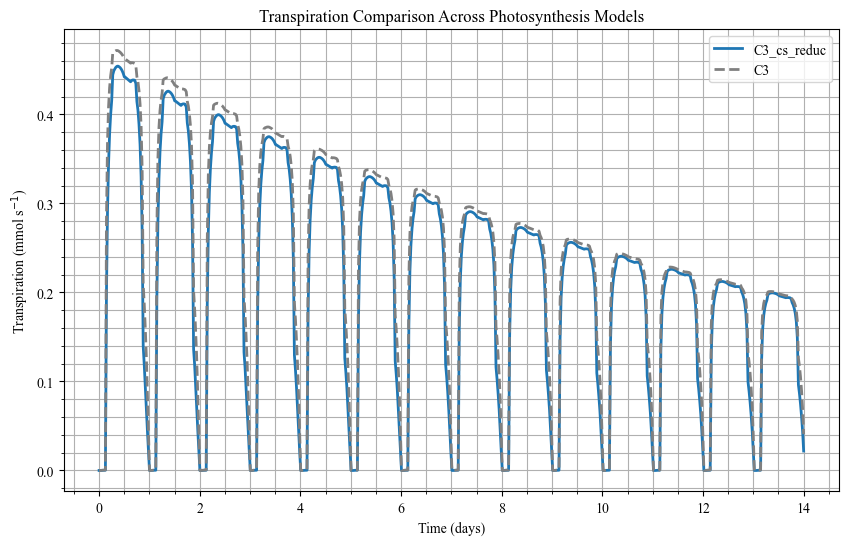

Integrated transpiration (C3_cs_reduc): 2.642 um
Integrated transpiration (C3): 2.834 um
Difference (C3_cs_reduc - C3): -0.193 um


In [134]:
# Compare transpiration between model variants (after both runs complete)
if 'results_by_model' not in globals():
    raise RuntimeError('Run the simulation cell above first to populate results_by_model.')

model_a = 'C3_cs_reduc'
model_b = 'C3'
required_models = [model_a, model_b]
missing_models = [m for m in required_models if m not in results_by_model]
if missing_models:
    raise ValueError(f"Missing model results: {missing_models}. Update selected_models and rerun.")

ev_a = np.array(results_by_model[model_a]['ev'])
ev_b = np.array(results_by_model[model_b]['ev'])
n_plot = min(len(ev_a), len(ev_b))

if 'daySteps' in globals() and 'dispDuration' in globals():
    n_plot = min(n_plot, int(daySteps * dispDuration))

if 'timevec' in globals() and len(timevec) >= n_plot:
    time_plot = np.array(timevec[:n_plot])
else:
    time_plot = np.arange(n_plot) * dt / (60.0 * 24.0)

# Convert from um/s to mmol/s
ev_a_mmol_s = ev_a[:n_plot] * 1000.0 / 18.0
ev_b_mmol_s = ev_b[:n_plot] * 1000.0 / 18.0

plt.figure(figsize=(10, 6))
plt.title('Transpiration Comparison Across Photosynthesis Models')
plt.xlabel('Time (days)')
plt.ylabel('Transpiration (mmol s$^{-1}$)')
plt.plot(time_plot, ev_a_mmol_s, linewidth=2, label=model_a)
plt.plot(time_plot, ev_b_mmol_s, linewidth=2, linestyle='--', color='gray', label=model_b)
plt.minorticks_on()
plt.grid(visible=True, which='both', axis='both')
plt.legend()
plt.show()

print(f"Integrated transpiration ({model_a}): {ev_a[:n_plot].sum():.3f} um")
print(f"Integrated transpiration ({model_b}): {ev_b[:n_plot].sum():.3f} um")
print(f"Difference ({model_a} - {model_b}): {(ev_a[:n_plot].sum() - ev_b[:n_plot].sum()):.3f} um")

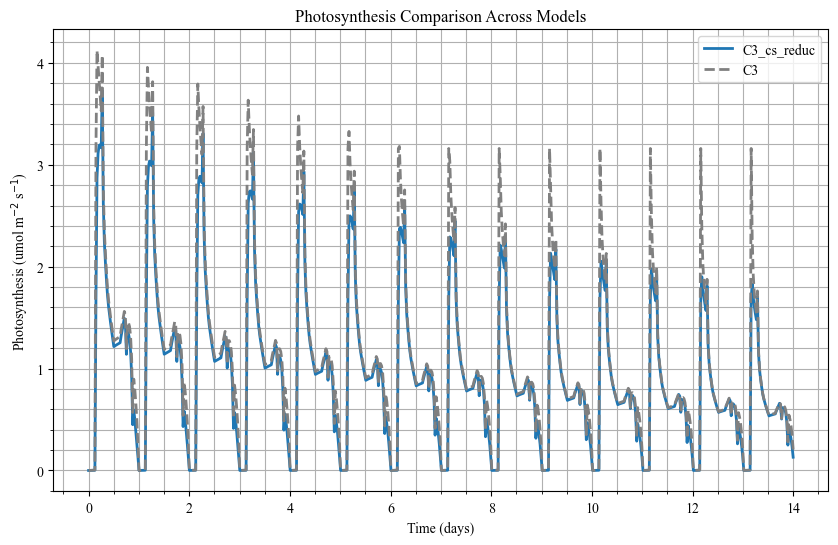

Integrated photosynthesis (C3_cs_reduc): 641.405 um
Integrated photosynthesis (C3): 719.690 um
Difference (C3_cs_reduc - C3): -78.285 um


In [135]:
# Compare photosynthesis between model variants (after both runs complete)
if 'results_by_model' not in globals():
    raise RuntimeError('Run the simulation cell above first to populate results_by_model.')

model_a = 'C3_cs_reduc'
model_b = 'C3'
required_models = [model_a, model_b]
missing_models = [m for m in required_models if m not in results_by_model]
if missing_models:
    raise ValueError(f"Missing model results: {missing_models}. Update selected_models and rerun.")

An_a = np.array(results_by_model[model_a]['a'])
An_b = np.array(results_by_model[model_b]['a'])
n_plot = min(len(An_a), len(An_b))

if 'daySteps' in globals() and 'dispDuration' in globals():
    n_plot = min(n_plot, int(daySteps * dispDuration))

if 'timevec' in globals() and len(timevec) >= n_plot:
    time_plot = np.array(timevec[:n_plot])
else:
    time_plot = np.arange(n_plot) * dt / (60.0 * 24.0)


plt.figure(figsize=(10, 6))
plt.title('Photosynthesis Comparison Across Models')
plt.xlabel('Time (days)')
plt.ylabel('Photosynthesis (umol m$^{-2}$ s$^{-1}$)')
plt.plot(time_plot, An_a, linewidth=2, label=model_a)
plt.plot(time_plot, An_b, linewidth=2, linestyle='--', color='gray', label=model_b)
plt.minorticks_on()
plt.grid(visible=True, which='both', axis='both')
plt.legend()
plt.show()

print(f"Integrated photosynthesis ({model_a}): {An_a[:n_plot].sum():.3f} um")
print(f"Integrated photosynthesis ({model_b}): {An_b[:n_plot].sum():.3f} um")
print(f"Difference ({model_a} - {model_b}): {(An_a[:n_plot].sum() - An_b[:n_plot].sum()):.3f} um")

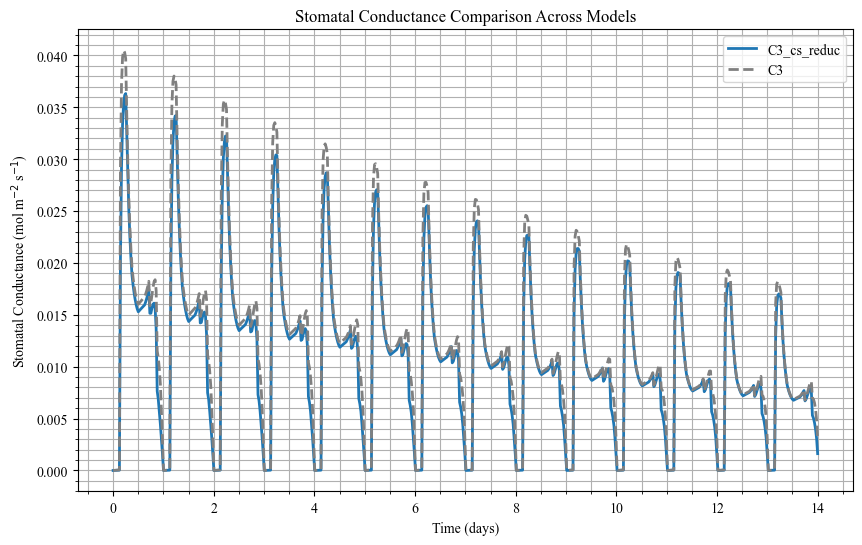

Mean stomatal conductance (C3_cs_reduc): 0.0109 mol m^-2 s^-1
Mean stomatal conductance (C3): 0.0119 mol m^-2 s^-1
Difference (C3_cs_reduc - C3): -0.0010 mol m^-2 s^-1


In [138]:
# Compare stomatal conductance between model variants (after both runs complete)
if 'results_by_model' not in globals():
    raise RuntimeError('Run the simulation cell above first to populate results_by_model.')

model_a = 'C3_cs_reduc'
model_b = 'C3'
required_models = [model_a, model_b]
missing_models = [m for m in required_models if m not in results_by_model]
if missing_models:
    raise ValueError(f"Missing model results: {missing_models}. Update selected_models and rerun.")

if 'gsw' not in results_by_model[model_a] or 'gsw' not in results_by_model[model_b]:
    raise KeyError("'gsw' is not present in one or both model outputs.")

gsw_a = np.array(results_by_model[model_a]['gsw'])
gsw_b = np.array(results_by_model[model_b]['gsw'])
n_plot = min(len(gsw_a), len(gsw_b))

if 'daySteps' in globals() and 'dispDuration' in globals():
    n_plot = min(n_plot, int(daySteps * dispDuration))

if 'timevec' in globals() and len(timevec) >= n_plot:
    time_plot = np.array(timevec[:n_plot])
else:
    time_plot = np.arange(n_plot) * dt / (60.0 * 24.0)

plt.figure(figsize=(10, 6))
plt.title('Stomatal Conductance Comparison Across Models')
plt.xlabel('Time (days)')
plt.ylabel('Stomatal Conductance (mol m$^{-2}$ s$^{-1}$)')
plt.plot(time_plot, gsw_a[:n_plot], linewidth=2, label=model_a)
plt.plot(time_plot, gsw_b[:n_plot], linewidth=2, linestyle='--', color='gray', label=model_b)
plt.minorticks_on()
plt.grid(visible=True, which='both', axis='both')
plt.legend()
plt.show()

print(f"Mean stomatal conductance ({model_a}): {np.mean(gsw_a[:n_plot]):.4f} mol m^-2 s^-1")
print(f"Mean stomatal conductance ({model_b}): {np.mean(gsw_b[:n_plot]):.4f} mol m^-2 s^-1")
print(f"Difference ({model_a} - {model_b}): {np.mean(gsw_a[:n_plot]) - np.mean(gsw_b[:n_plot]):.4f} mol m^-2 s^-1")

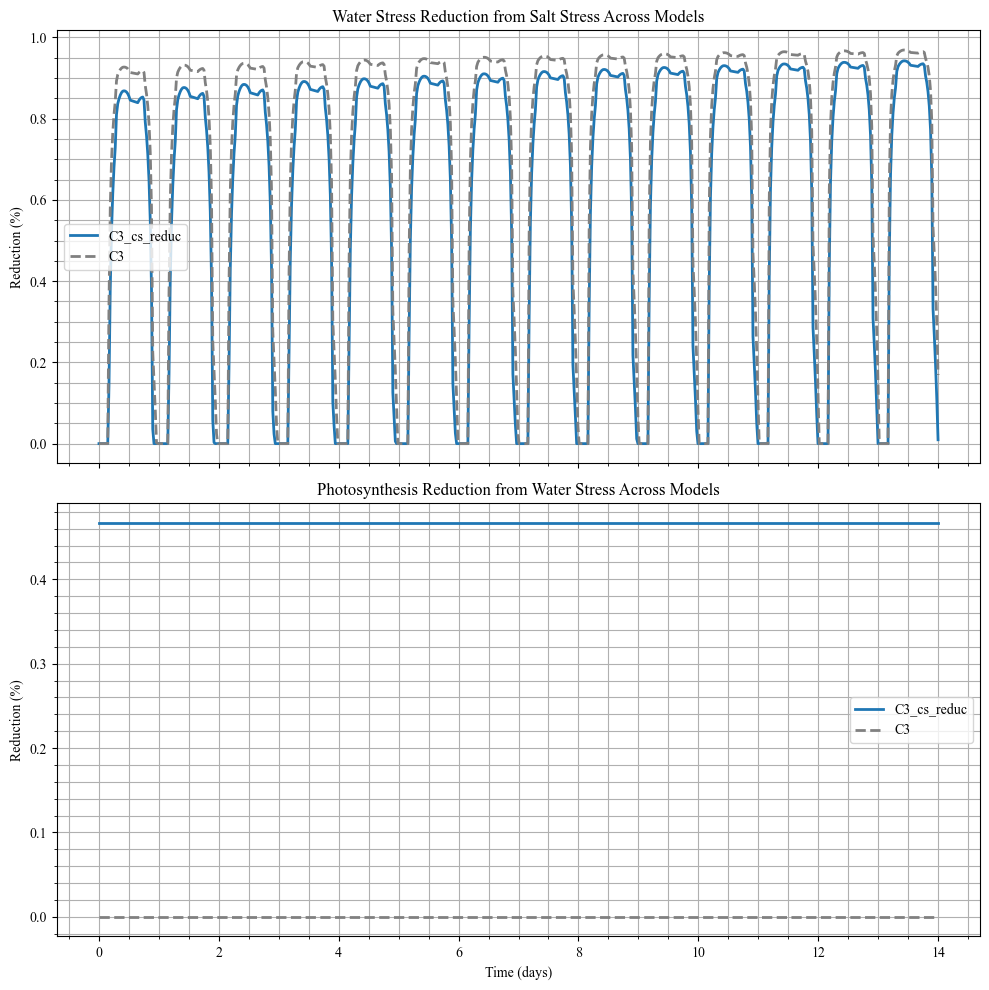

In [136]:
# Compare photosynthesis reduction from salt stress and from water stress between models
if 'results_by_model' not in globals():
    raise RuntimeError('Run the simulation cell above first to populate results_by_model.')

model_a = 'C3_cs_reduc'
model_b = 'C3'
required_models = [model_a, model_b]
missing_models = [m for m in required_models if m not in results_by_model]
if missing_models:
    raise ValueError(f"Missing model results: {missing_models}. Update selected_models and rerun.")

psi_l_reduc_a = np.array(results_by_model[model_a]['psi_l_reduc'])
psi_l_reduc_b = np.array(results_by_model[model_b]['psi_l_reduc'])
cs_reduc_a = np.array(results_by_model[model_a]['cs_reduc'])
cs_reduc_b = np.array(results_by_model[model_b]['cs_reduc'])
n_plot = min(len(psi_l_reduc_a), len(psi_l_reduc_b), len(cs_reduc_a), len(cs_reduc_b))

if 'daySteps' in globals() and 'dispDuration' in globals():
    n_plot = min(n_plot, int(daySteps * dispDuration))

if 'timevec' in globals() and len(timevec) >= n_plot:
    time_plot = np.array(timevec[:n_plot])
else:
    time_plot = np.arange(n_plot) * dt / (60.0 * 24.0)

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

axes[0].set_title('Water Stress Reduction from Salt Stress Across Models')
axes[0].set_ylabel('Reduction (%)')
axes[0].plot(time_plot, psi_l_reduc_a[:n_plot], linewidth=2, label=model_a)
axes[0].plot(time_plot, psi_l_reduc_b[:n_plot], linewidth=2, linestyle='--', color='gray', label=model_b)
axes[0].minorticks_on()
axes[0].grid(visible=True, which='both', axis='both')
axes[0].legend()

axes[1].set_title('Photosynthesis Reduction from Water Stress Across Models')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Reduction (%)')
axes[1].plot(time_plot, cs_reduc_a[:n_plot], linewidth=2, label=model_a)
axes[1].plot(time_plot, cs_reduc_b[:n_plot], linewidth=2, linestyle='--', color='gray', label=model_b)
axes[1].minorticks_on()
axes[1].grid(visible=True, which='both', axis='both')
axes[1].legend()

plt.tight_layout()
plt.show()

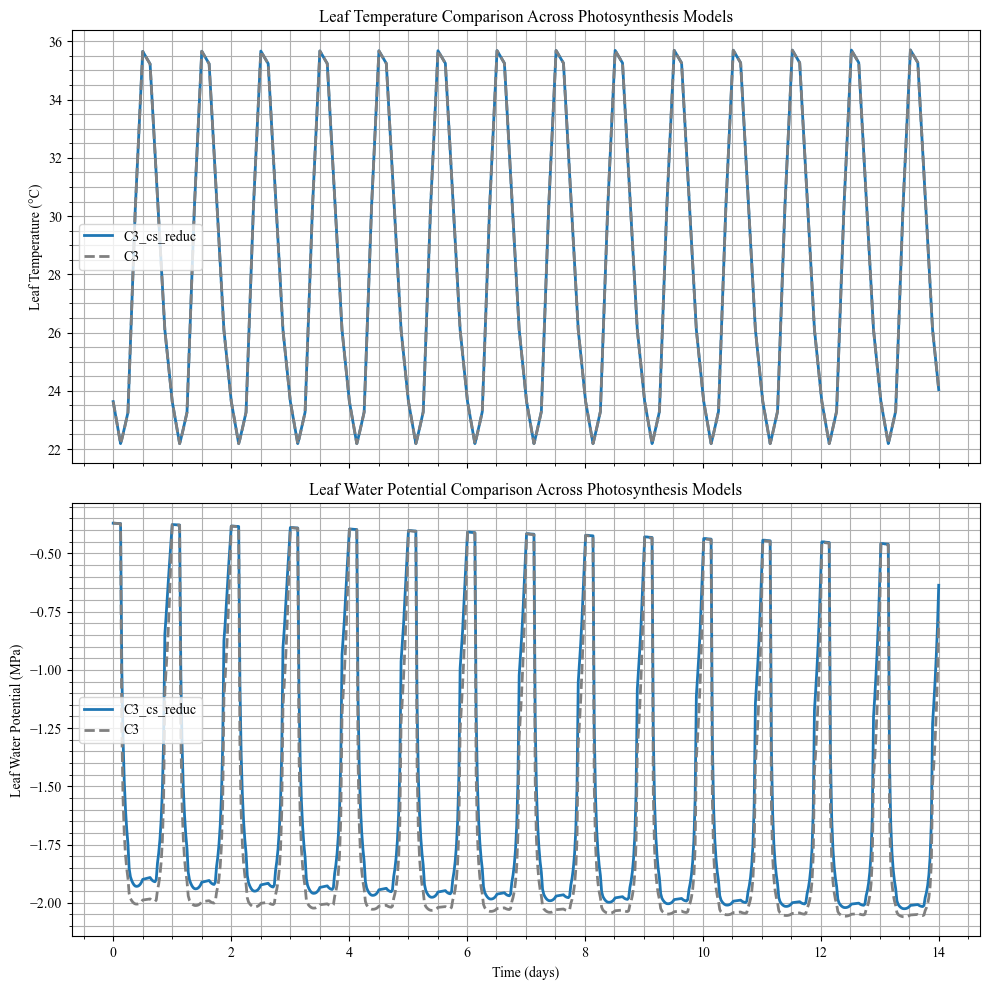

In [137]:
# Compare leaf temperature (tl) and leaf water potential (psi_l) between model variants
if 'results_by_model' not in globals():
    raise RuntimeError('Run the simulation cell above first to populate results_by_model.')

model_a = 'C3_cs_reduc'
model_b = 'C3'
required_models = [model_a, model_b]
missing_models = [m for m in required_models if m not in results_by_model]
if missing_models:
    raise ValueError(f"Missing model results: {missing_models}. Update selected_models and rerun.")

tl_a = np.array(results_by_model[model_a]['tl'])
tl_b = np.array(results_by_model[model_b]['tl'])
psil_a = np.array(results_by_model[model_a]['psi_l'])
psil_b = np.array(results_by_model[model_b]['psi_l'])
n_plot = min(len(tl_a), len(tl_b), len(psil_a), len(psil_b))

if 'daySteps' in globals() and 'dispDuration' in globals():
    n_plot = min(n_plot, int(daySteps * dispDuration))

if 'timevec' in globals() and len(timevec) >= n_plot:
    time_plot = np.array(timevec[:n_plot])
else:
    time_plot = np.arange(n_plot) * dt / (60.0 * 24.0)

# Convert leaf temperature from Kelvin to Celsius
tl_a_c = tl_a[:n_plot] - 273.15
tl_b_c = tl_b[:n_plot] - 273.15

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

axes[0].set_title('Leaf Temperature Comparison Across Photosynthesis Models')
axes[0].set_ylabel('Leaf Temperature (°C)')
axes[0].plot(time_plot, tl_a_c, linewidth=2, label=model_a)
axes[0].plot(time_plot, tl_b_c, linewidth=2, linestyle='--', color='gray', label=model_b)
axes[0].minorticks_on()
axes[0].grid(visible=True, which='both', axis='both')
axes[0].legend()

axes[1].set_title('Leaf Water Potential Comparison Across Photosynthesis Models')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Leaf Water Potential (MPa)')
axes[1].plot(time_plot, psil_a[:n_plot], linewidth=2, label=model_a)
axes[1].plot(time_plot, psil_b[:n_plot], linewidth=2, linestyle='--', color='gray', label=model_b)
axes[1].minorticks_on()
axes[1].grid(visible=True, which='both', axis='both')
axes[1].legend()

plt.tight_layout()
plt.show()

## Water Balance Diagnostics
Check water balance closure at nodes B (root/soil interface) and X (xylem junction).

In [12]:
# Calculate water balance at both nodes
node_b_balance = (np.array(results['qbx']) - 
                  np.array(results['qs'][0]) - 
                  np.array(results['qs'][1]))

node_x_balance = (np.array(results['qbx']) + 
                  np.array(results['qw']) - 
                  np.array(results['ev']))

print("Water Balance Diagnostics:")
print(f"  Node B (root interface) mean balance: {node_b_balance.mean():.6e} μm/s")
print(f"  Node X (xylem junction) mean balance: {node_x_balance.mean():.6e} μm/s")
print(f"\n  Node B max absolute error: {np.abs(node_b_balance).max():.6e} μm/s")
print(f"  Node X max absolute error: {np.abs(node_x_balance).max():.6e} μm/s")

# Calculate relative error for Node X
mean_flux = np.mean(np.abs(results['ev']))
rel_error_x = np.abs(node_x_balance.mean()) / mean_flux * 100
print(f"\n  Node X relative error: {rel_error_x:.3f}% of mean transpiration flux")

Water Balance Diagnostics:
  Node B (root interface) mean balance: -1.320769e-19 μm/s
  Node X (xylem junction) mean balance: -2.009101e-06 μm/s

  Node B max absolute error: 4.813858e-17 μm/s
  Node X max absolute error: 1.290730e-04 μm/s

  Node X relative error: 0.048% of mean transpiration flux
